In [1]:
import yfinance as yf
import pandas as pd

# Download NIFTY 50 historical data
data = yf.download(
    "^NSEI",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False
)

# Display the first few rows
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price         Adj Close        Close         High          Low         Open  \
Ticker            ^NSEI        ^NSEI        ^NSEI        ^NSEI        ^NSEI   
Date                                                                          
2015-01-02  8395.450195  8395.450195  8410.599609  8288.700195  8288.700195   
2015-01-05  8378.400391  8378.400391  8445.599609  8363.900391  8407.950195   
2015-01-06  8127.350098  8127.350098  8327.849609  8111.350098  8325.299805   
2015-01-07  8102.100098  8102.100098  8151.200195  8065.450195  8118.649902   
2015-01-08  8234.599609  8234.599609  8243.500000  8167.299805  8191.399902   

Price       Volume  
Ticker       ^NSEI  
Date                
2015-01-02  101900  
2015-01-05  118200  
2015-01-06  172800  
2015-01-07  164100  
2015-01-08  143800  


In [2]:
print(data.shape)

(2708, 6)


In [3]:
print(data.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 2708 entries, 2015-01-02 to 2025-12-31
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Adj Close, ^NSEI)  2708 non-null   float64
 1   (Close, ^NSEI)      2708 non-null   float64
 2   (High, ^NSEI)       2708 non-null   float64
 3   (Low, ^NSEI)        2708 non-null   float64
 4   (Open, ^NSEI)       2708 non-null   float64
 5   (Volume, ^NSEI)     2708 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 148.1 KB
None


In [4]:
# Check the column names
print(data.columns)

# Check summary statistics
print(data.describe())

MultiIndex([('Adj Close', '^NSEI'),
            (    'Close', '^NSEI'),
            (     'High', '^NSEI'),
            (      'Low', '^NSEI'),
            (     'Open', '^NSEI'),
            (   'Volume', '^NSEI')],
           names=['Price', 'Ticker'])
Price      Adj Close         Close          High           Low          Open  \
Ticker         ^NSEI         ^NSEI         ^NSEI         ^NSEI         ^NSEI   
count    2708.000000   2708.000000   2708.000000   2708.000000   2708.000000   
mean    14524.487398  14524.487398  14599.350163  14446.272279  14533.445386   
std      5723.006293   5723.006293   5743.236522   5700.784707   5721.949350   
min      6970.600098   6970.600098   7034.200195   6825.799805   7023.649902   
25%      9819.212402   9819.212402   9886.849609   9752.474609   9823.324707   
50%     11919.350098  11919.350098  11977.000000  11860.650391  11934.775391   
75%     18299.662598  18299.662598  18367.775391  18216.149414  18314.974609   
max     26216.050781  262

In [5]:
# Extract NIFTY 50 closing prices
close_price = data[("Close", "^NSEI")]

# Create a new DataFrame
df = pd.DataFrame({
    "Date": close_price.index,
    "Close": close_price.values
})

# Display the first 5 observations
print(df.head())

        Date        Close
0 2015-01-02  8395.450195
1 2015-01-05  8378.400391
2 2015-01-06  8127.350098
3 2015-01-07  8102.100098
4 2015-01-08  8234.599609


In [6]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2708 entries, 0 to 2707
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    2708 non-null   datetime64[s]
 1   Close   2708 non-null   float64      
dtypes: datetime64[s](1), float64(1)
memory usage: 42.4 KB
None
Date     0
Close    0
dtype: int64


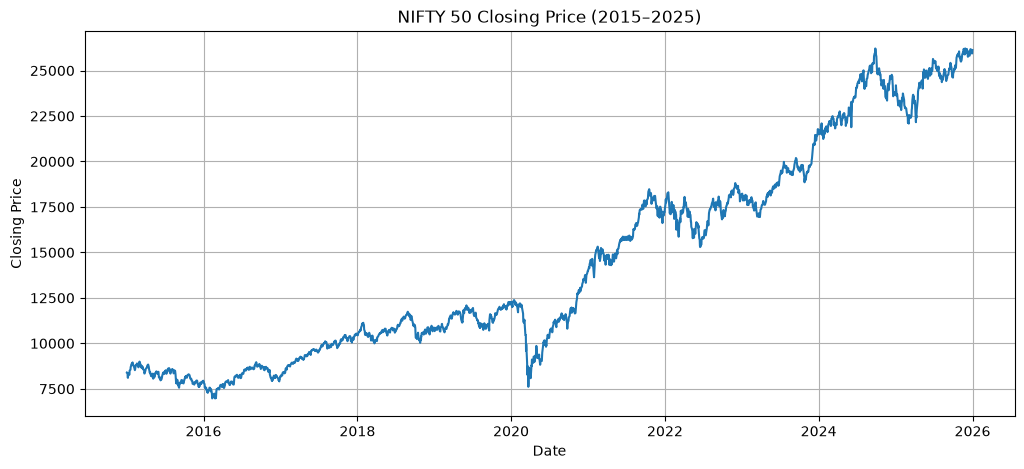

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Close"])

plt.title("NIFTY 50 Closing Price (2015–2025)")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)
plt.show()

In [8]:
import numpy as np

# Calculate daily log returns
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))

# Display the first few observations
print(df.head())

        Date        Close  Log_Return
0 2015-01-02  8395.450195         NaN
1 2015-01-05  8378.400391   -0.002033
2 2015-01-06  8127.350098   -0.030422
3 2015-01-07  8102.100098   -0.003112
4 2015-01-08  8234.599609    0.016221


In [9]:
df = df.dropna()

print(df.head())
print(df.shape)

        Date        Close  Log_Return
1 2015-01-05  8378.400391   -0.002033
2 2015-01-06  8127.350098   -0.030422
3 2015-01-07  8102.100098   -0.003112
4 2015-01-08  8234.599609    0.016221
5 2015-01-09  8284.500000    0.006042
(2707, 3)


In [10]:
print(df["Log_Return"].describe())

count    2707.000000
mean        0.000419
std         0.010296
min        -0.139038
25%        -0.004280
50%         0.000604
75%         0.005855
max         0.084003
Name: Log_Return, dtype: float64


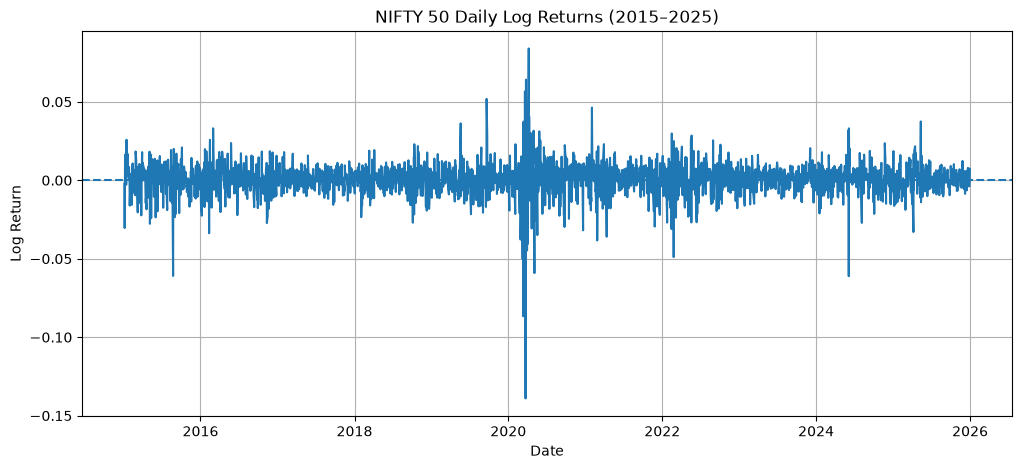

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Log_Return"])

plt.title("NIFTY 50 Daily Log Returns (2015–2025)")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.axhline(y=0, linestyle="--")
plt.grid(True)

plt.show()

In [12]:
# Calculate squared returns
df["Squared_Return"] = df["Log_Return"] ** 2

# Display the first few observations
print(df[["Date", "Log_Return", "Squared_Return"]].head())

        Date  Log_Return  Squared_Return
1 2015-01-05   -0.002033        0.000004
2 2015-01-06   -0.030422        0.000926
3 2015-01-07   -0.003112        0.000010
4 2015-01-08    0.016221        0.000263
5 2015-01-09    0.006042        0.000037


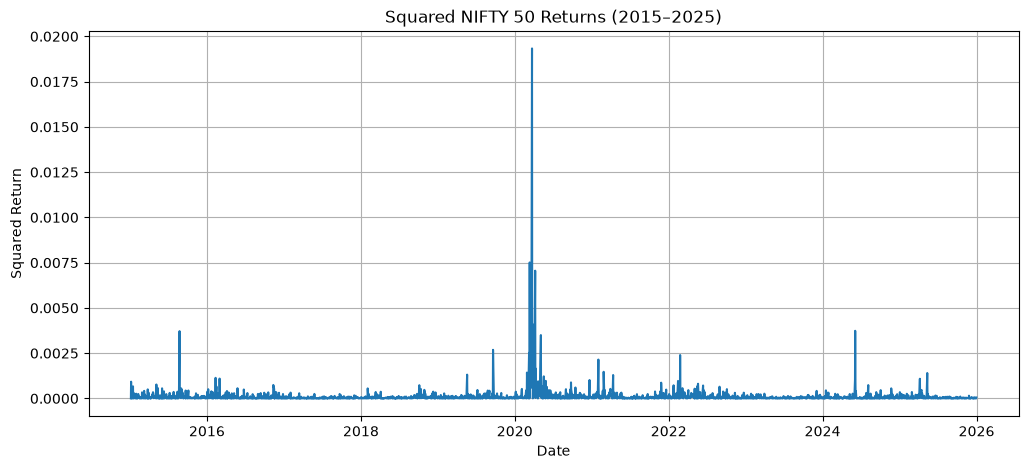

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Squared_Return"])

plt.title("Squared NIFTY 50 Returns (2015–2025)")
plt.xlabel("Date")
plt.ylabel("Squared Return")

plt.grid(True)
plt.show()

In [15]:
!pip install statsmodels

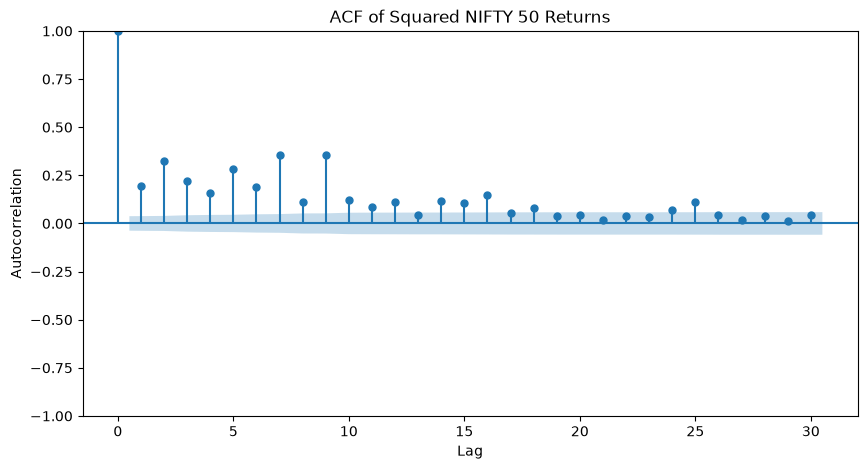

In [16]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 5))

plot_acf(
    df["Squared_Return"],
    lags=30,
    ax=plt.gca()
)

plt.title("ACF of Squared NIFTY 50 Returns")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

In [17]:
!pip install arch

   ---------------------------------------- 0.0/934.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/934.4 kB ? eta -:--:--
   --------------------------------- ------ 786.4/934.4 kB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 934.4/934.4 kB 2.1 MB/s  0:00:00


In [18]:
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch

# ARCH-LM test on daily log returns
arch_test = het_arch(df["Log_Return"], nlags=10)

print("LM Statistic:", arch_test[0])
print("LM Test p-value:", arch_test[1])
print("F Statistic:", arch_test[2])
print("F Test p-value:", arch_test[3])

LM Statistic: 700.209117215387
LM Test p-value: 5.663409390872741e-144
F Statistic: 94.18921656021004
F Test p-value: 2.950900756728624e-167


In [19]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test
adf_result = adfuller(df["Log_Return"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags:", adf_result[2])
print("Number of Observations:", adf_result[3])

ADF Statistic: -14.450989592324532
p-value: 7.099077767043647e-27
Number of Lags: 11
Number of Observations: 2695


In [20]:
from arch import arch_model

# Convert returns to percentage scale
returns = df["Log_Return"] * 100

# Build GARCH(1,1) model
garch_model = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1
)

# Fit the model
garch_result = garch_model.fit(disp="off")

# Display results
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3458.57
Distribution:                  Normal   AIC:                           6925.13
Method:            Maximum Likelihood   BIC:                           6948.75
                                        No. Observations:                 2707
Date:                Sat, Aug 01 2026   Df Residuals:                     2706
Time:                        15:13:42   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0675  1.630e-02      4.139  3.483e-05 [3.

In [21]:
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3458.57
Distribution:                  Normal   AIC:                           6925.13
Method:            Maximum Likelihood   BIC:                           6948.75
                                        No. Observations:                 2707
Date:                Sat, Aug 01 2026   Df Residuals:                     2706
Time:                        15:13:42   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0675  1.630e-02      4.139  3.483e-05 [3.

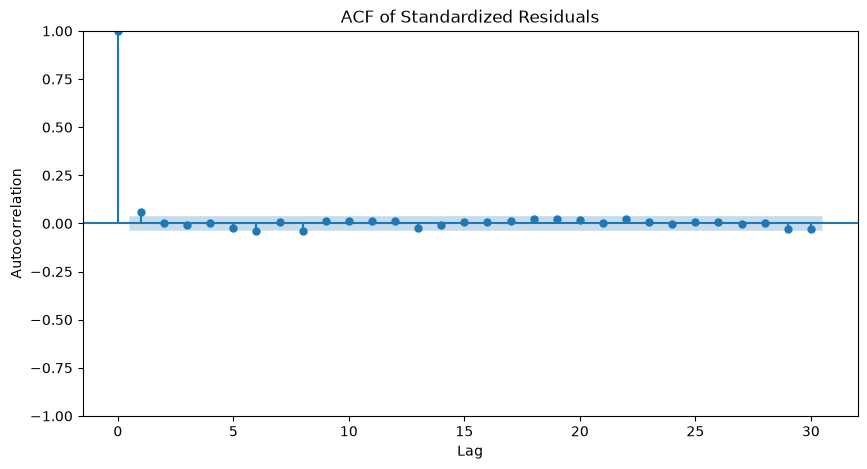

In [22]:
# Get standardized residuals
standardized_residuals = garch_result.std_resid

# Plot ACF of standardized residuals
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 5))

plot_acf(
    standardized_residuals,
    lags=30,
    ax=plt.gca()
)

plt.title("ACF of Standardized Residuals")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

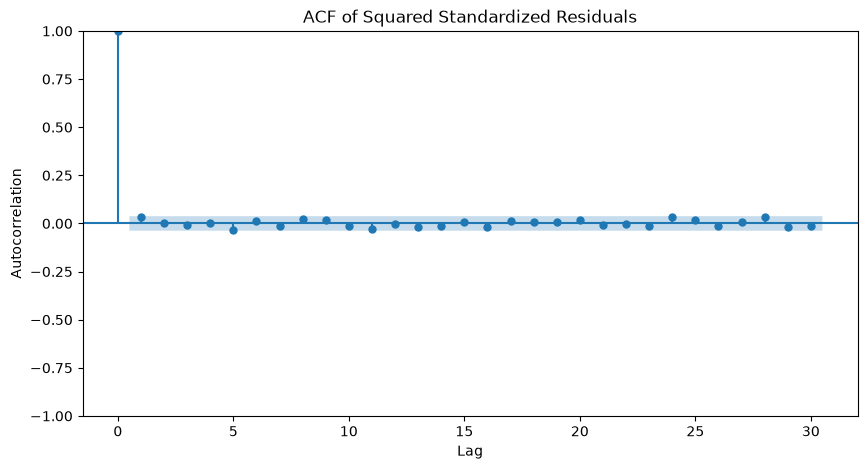

In [23]:
# Squared standardized residuals
squared_std_residuals = standardized_residuals ** 2

# Plot ACF
plt.figure(figsize=(10, 5))

plot_acf(
    squared_std_residuals,
    lags=30,
    ax=plt.gca()
)

plt.title("ACF of Squared Standardized Residuals")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

In [24]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box test on squared standardized residuals
lb_test = acorr_ljungbox(
    squared_std_residuals,
    lags=[10, 20],
    return_df=True
)

print(lb_test)

      lb_stat  lb_pvalue
10   9.162294   0.516774
20  15.596494   0.741320


In [25]:
# Forecast volatility for the next 10 trading days
forecast = garch_result.forecast(horizon=10)

# Extract forecasted variance
variance_forecast = forecast.variance.iloc[-1]

# Convert variance to volatility
volatility_forecast = np.sqrt(variance_forecast)

# Create a forecast table
forecast_table = pd.DataFrame({
    "Day": range(1, 11),
    "Forecasted_Volatility": volatility_forecast.values
})

print(forecast_table)

   Day  Forecasted_Volatility
0    1               0.598080
1    2               0.610727
2    3               0.622828
3    4               0.634422
4    5               0.645541
5    6               0.656217
6    7               0.666476
7    8               0.676343
8    9               0.685841
9   10               0.694990


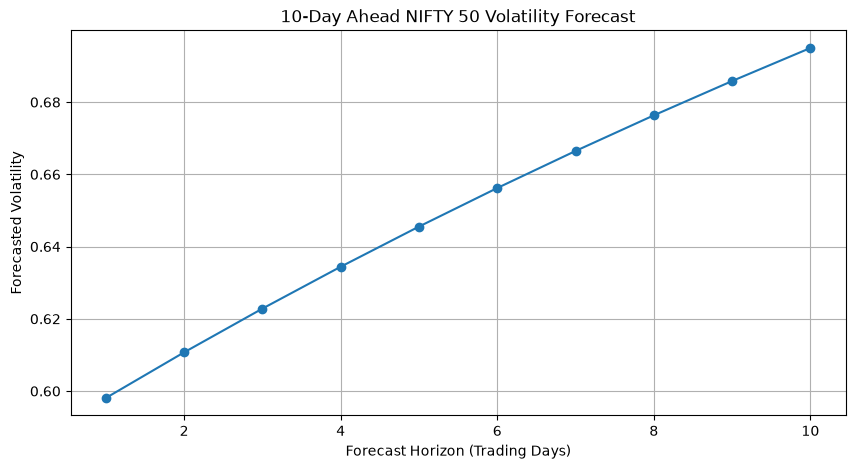

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    forecast_table["Day"],
    forecast_table["Forecasted_Volatility"],
    marker="o"
)

plt.title("10-Day Ahead NIFTY 50 Volatility Forecast")
plt.xlabel("Forecast Horizon (Trading Days)")
plt.ylabel("Forecasted Volatility")

plt.grid(True)
plt.show()